In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer

In [3]:
df = pd.read_csv("Message_Intelligence_Dataset_5200 - Message_Intelligence_Dataset_5200.csv.csv")
df

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,905196,Thanks for your help on the project update. th...,73,12,0,0,0,0,1,23.1,262.0,5.0,2025-10-28 13:00:00,13,1,0
5196,905197,Let's catch up tomorrow regarding the timeline...,108,12,1,4,0,0,0,62.4,398.0,6.0,2025-11-25 14:00:00,14,1,0
5197,905198,Here are the notes from today's discussion. th...,80,12,0,0,0,0,1,96.6,457.0,5.0,2025-10-29 14:00:00,14,2,0
5198,905199,Act fast! Your account will be suspended unles...,94,14,1,4,2,1,0,70.1,9.0,11.0,2025-11-20 23:00:00,23,3,1


In [4]:
df.shape

(5200, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

In [7]:
df.describe()

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5094.000000,5087.000000,5038.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.836317,296.671909,8.301906,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.697943,191.748754,5.586503,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.100000,148.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.600000,410.500000,10.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


In [8]:
df.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

In [11]:
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


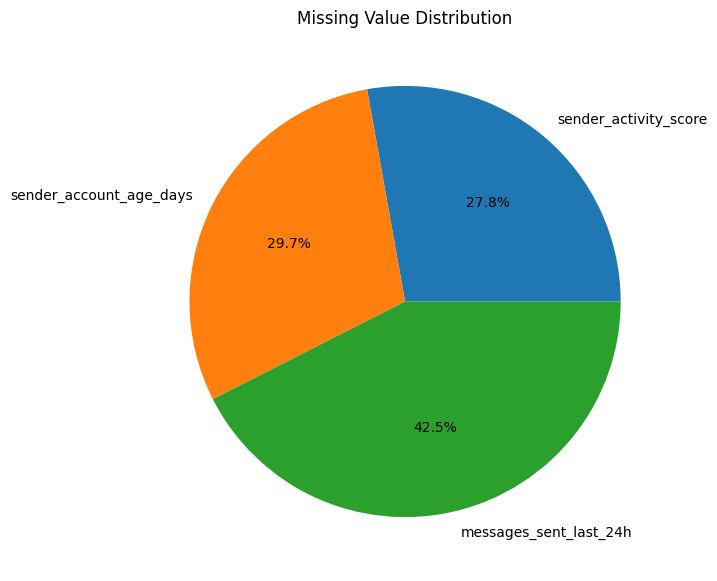

In [14]:
missing_value = df.isnull().sum()
plt.figure(figsize=(7, 7))
missing_value[missing_value > 0].plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Missing Value Distribution")
plt.show()

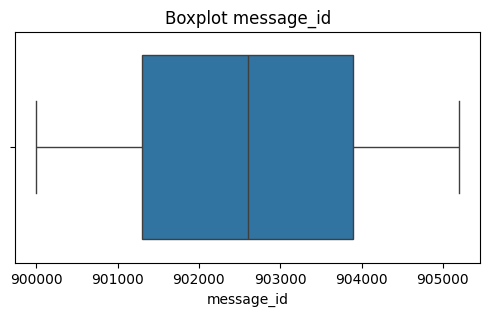

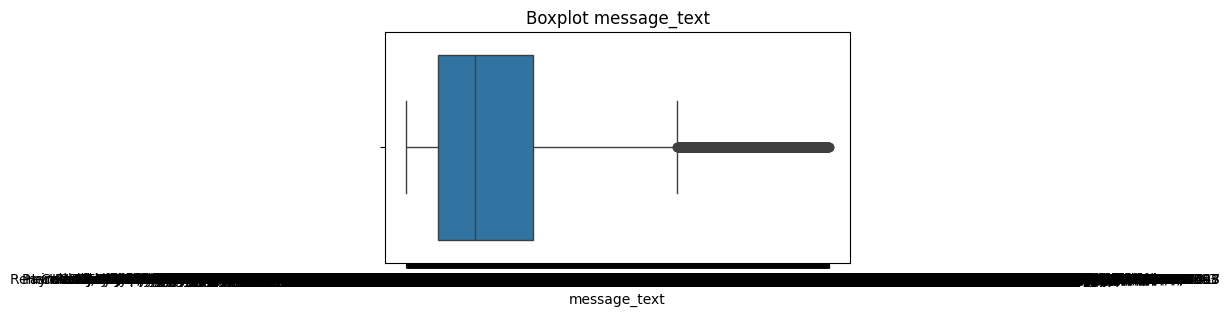

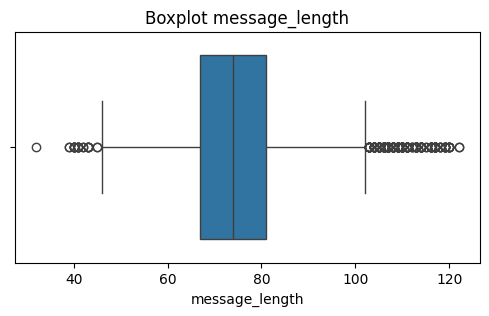

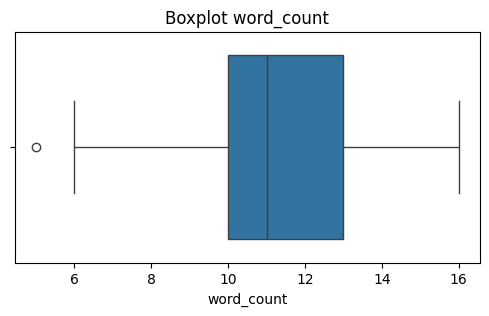

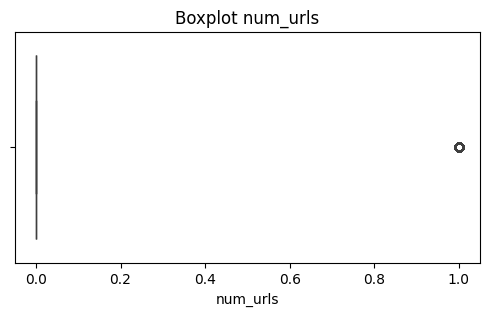

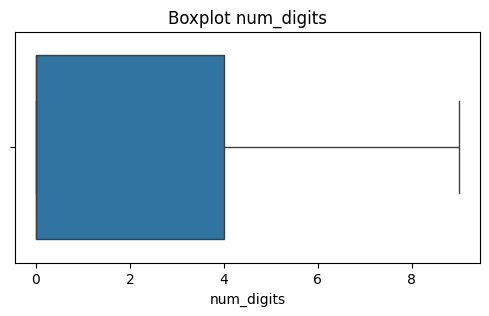

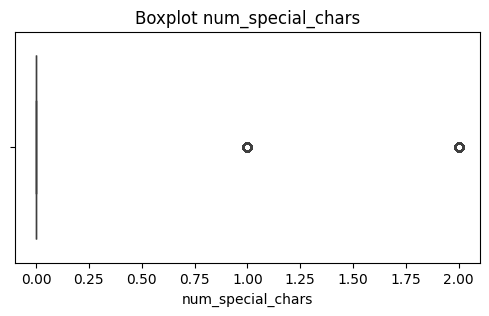

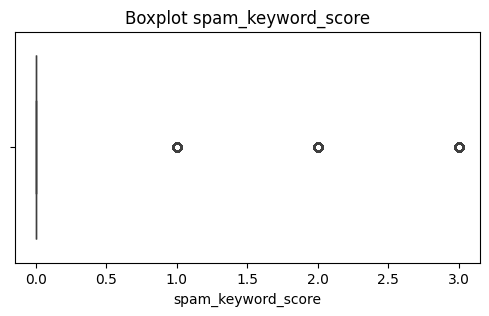

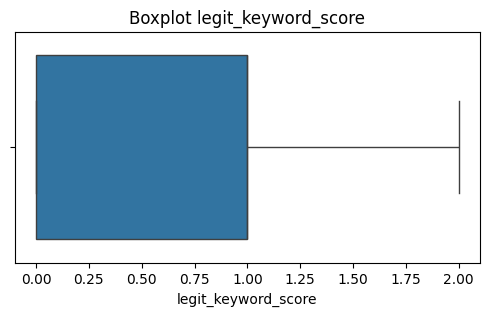

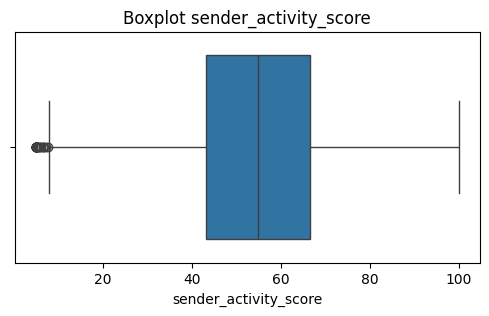

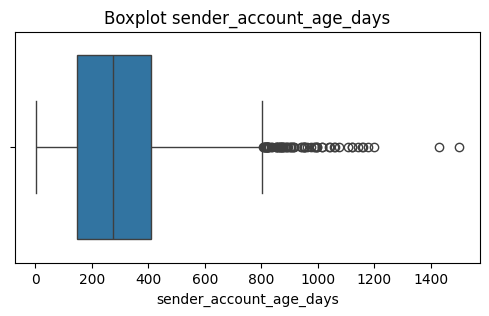

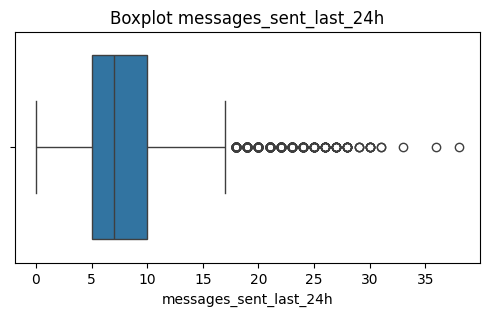

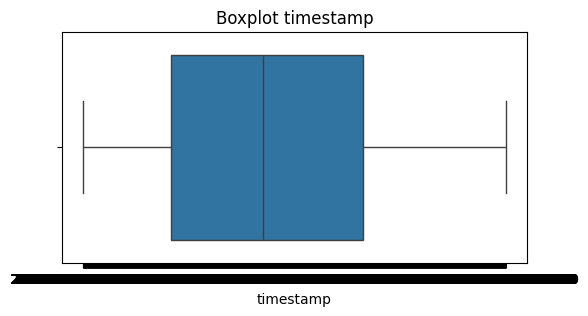

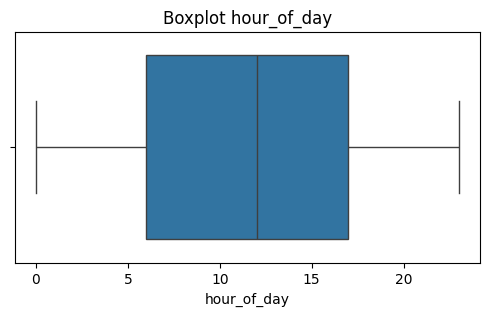

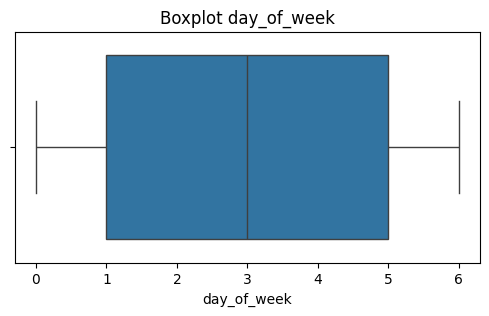

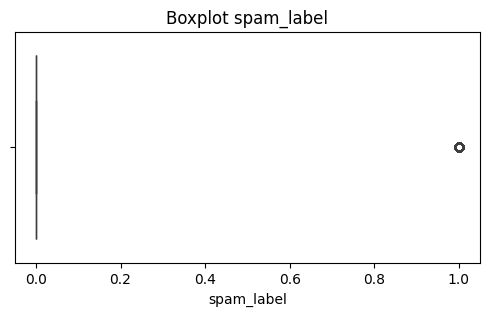

In [16]:
columns = df.columns
for col in columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x =df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

In [18]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['message_id', 'message_length', 'word_count', 'num_urls', 'num_digits',
       'num_special_chars', 'spam_keyword_score', 'legit_keyword_score',
       'sender_activity_score', 'sender_account_age_days',
       'messages_sent_last_24h', 'hour_of_day', 'day_of_week', 'spam_label'],
      dtype='object')
Categorical Columns: Index(['message_text', 'timestamp'], dtype='object')


In [19]:
imputer = SimpleImputer(strategy="mean")
data = df.copy()
data[num_cols] = imputer.fit_transform(data[num_cols])
data.isnull().sum()

message_id                 0
message_text               0
message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
timestamp                  0
hour_of_day                0
day_of_week                0
spam_label                 0
dtype: int64

In [28]:
X = data.drop(columns=["spam_label", "message_id", "message_text","timestamp"])
y = data["spam_label"] 


In [31]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
X_scal = Scaler.fit_transform(X)
X_scal

array([[ 1.92417639, -0.28423609,  1.96002888, ..., -0.41866164,
        -1.38808609, -1.4735185 ],
       [-0.16347617,  0.33730624, -0.51019656, ..., -1.50991834,
         1.38124684, -0.50373035],
       [-0.64524214,  0.95884858, -0.51019656, ..., -0.41866164,
         0.21521193,  0.95095188],
       ...,
       [ 0.39858414,  0.33730624, -0.51019656, ..., -0.60053776,
         0.36096629, -0.50373035],
       [ 1.52270474,  1.58039092,  1.96002888, ...,  0.49071895,
         1.67275557, -0.01883627],
       [-0.32406482, -2.1488631 ,  1.96002888, ...,  0.49071895,
        -0.36780553, -0.98862442]])

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scal,y,random_state=42,test_size=0.2)

In [ ]:
X_train.shape

(4160, 12)

In [34]:
X_test.shape

(1040, 12)

In [35]:
y_train.shape

(4160,)

In [36]:
y_test.shape

(1040,)

## Part C: Baseline Model – K-Nearest Neighbors (KNN)

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [39]:
y_pred = knn.predict(X_test)
y_pred

array([1., 1., 0., ..., 0., 0., 0.])

In [40]:
accuracy_score(y_pred,y_test)

1.0

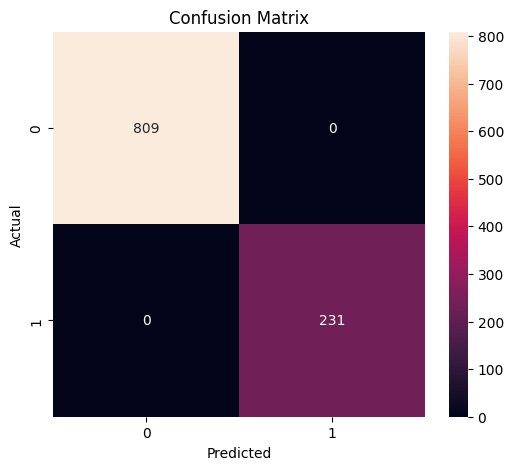

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [47]:
for k in [1,3,5,7,9,11,13]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"K={k} --> Accuracy={acc:.4f}")

K=1 --> Accuracy=1.0000
K=3 --> Accuracy=1.0000
K=5 --> Accuracy=1.0000
K=7 --> Accuracy=1.0000
K=9 --> Accuracy=1.0000
K=11 --> Accuracy=1.0000
K=13 --> Accuracy=1.0000


In [51]:
metrics = ['euclidean', 'manhattan']
for metric in metrics:
    model = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{metric} Accuracy = {acc:.4f}")

euclidean Accuracy = 1.0000
manhattan Accuracy = 1.0000


In [52]:
misclassified = np.sum(
    y_test != y_pred
)
correct = len(y_test) - misclassified
print("Misclassified:", misclassified)

Misclassified: 0


## Part D: Support Vector Machine (SVM)